In [4]:
import pandas as pd
vdb = pd.read_csv('vandenBerg_table2.csv') #import data from csv file, label it as vdb for convenience
print(vdb) #prints vdb so that the column titles are visible

    #NGC   Name   FeH    Age  Age_err Method   Figs        Range  HBtype  \
0    104  47Tuc -0.76  11.75     0.25      V     14  11.50–11.75   -0.99   
1    288   XXXX -1.32  11.50     0.38      H     24          NaN    0.98   
2    362   XXXX -1.30  10.75     0.25      V     13  10.75–11.00   -0.87   
3   1261   XXXX -1.27  10.75     0.25      V     13  10.75–11.25   -0.71   
4   1851   XXXX -1.18  11.00     0.25      V     13  10.75–11.25   -0.32   
5   2808   XXXX -1.18  11.00     0.38      V     13  11.00–11.25   -0.49   
6   3201   XXXX -1.51  11.50     0.38      A  12-30  11.25–11.75    0.08   
7   4147   XXXX -1.78  12.25     0.25      V     11  12.25–12.50    0.66   
8   4590    M68 -2.27  12.00     0.25      V     11        12.00    0.17   
9   4833   XXXX -1.89  12.50     0.50      A     30          NaN    0.93   
10  5024    M53 -2.06  12.25     0.25      V     12  12.25–12.50    0.81   
11  5053   XXXX -2.30  12.25     0.38      A     12  12.25–12.50    0.52   
12  5272    

**Notes on meaning of columns in the Table**
- **NGC** refers to New General Catalogue of nebulae and stellar clusters source: [Wikipedia](https://en.wikipedia.org/wiki/New_General_Catalogue)
- **FeH** is metallicity - log of ratio of iron and hydrogen comparative to the sun - check how this works
- The **Method** column refers to the method used to determine age - Vertical (V), Horizontal (H), Average of the two (A). I think that this is to do with how the isochrone that was fitted to the observed Colour Magnitude Diagram (CMD) was shifted (horizontally to match colour for example). Specifically, the vertical method compares the main sequence turn-off and the horizontal branch (HB), whereas the horizontal method compares the turnoff and the red giant branch
- The **Range** column refers to the range of ages determined by independent participants who determined the age based on their method
- **$v_e,0$** is the central escape velocity of the globular cluster, determined based on their estimations of the GC mass
- The GC mass was determined by assuming a Mass-to-Light ratio of $1.6(M/L_v)_\odot$, but this is not given in the table
- **R_G** is the galactocentric distance in kpc
- **M_V** is the absolute integrated magnitude in the visual band
- **HB Type** is to do with the distribution of stars around the 'instability strip' on the HB, given by $\frac{B-R}{B+V+R}$, where B is the number of stars on the HB to the left (blue) of the instability strip, V is the number of 'variable' stars within the instability strip (dominated by pulsating stars), and R is the number of stars to the right (red) of the instability strip.
-  **$log(\sigma_0)$** is the "common logarithm of the surface density of stars at the cluster center"


**notes on Van den Berg paper**
- " "low metallicities are not the exclusive result of an
earlier birth time compared to metal-rich disk and bulge GCs, but rather the result of a
lower mass host, considering the (observed) mass-metallicity relation in galaxies." In other
words, metal-poor globular clusters could simply be those systems that happened to form in
dwarf galaxies of low metallicity at whatever time the birth event occurred" (page 3)
- 

In [5]:
metallicity = vdb['FeH'] #extracts the column titled FeH and labels it metallicity
age = vdb['Age'] # age of the globular cluster in Gyr 
hbt = vdb['HBtype'] # Horizontal branch type (defined in Markdown cell above)
R_galaxy = vdb['R_G'] # galactocentric radius in kpc
magnitude = vdb['M_V'] # absolute integrated magnitude in the visual band
vel_esc = vdb['v_e0'] # escape velocity from the centre of the globular cluster in kms^-1 (proportional to sqrt(mass) I think)
stellar_density = vdb['log_sigma_0'] #log of the surfac density of stars at the cluster center




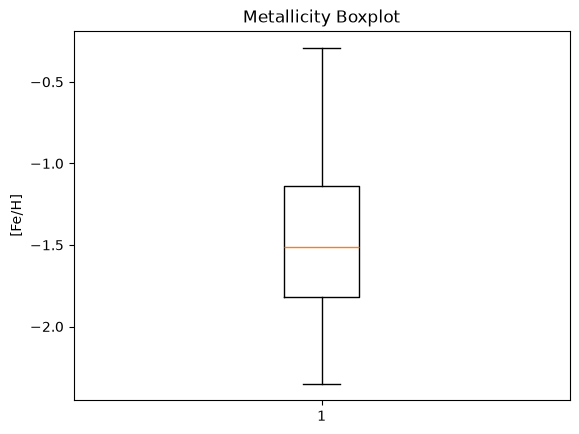

In [27]:
import matplotlib.pyplot as plt
feh = pd.DataFrame(metallicity) #This makes the column of metallicity easier to put into a box plot - turns it into its own data instead of being a subset of vdb
plt.boxplot(feh)
plt.title('Metallicity Boxplot')
plt.ylabel('[Fe/H]')
plt.show()



In [25]:
#This entire cell is me checking the metallicity column for outliers manually
#in order to check that the reason there's no outliers on my boxplot
#isn't just because I did something wrong while making it
from scipy import stats
import numpy as np
print('mean metallicity =', np.mean(feh))
from numpy import quantile
Q1_feh = quantile(metallicity, [0.25]) # define 1st quartile of metallicity
Q3_feh = quantile(metallicity,[0.75]) # define 3rd quartile of metallicity
iqr_feh = stats.iqr(metallicity) # finds IQR (could also be done by Q3-Q1)
print('Q1=',Q1_feh)
print('Q3=',Q3_feh)
print('IQR =', iqr_feh)
print('outlier cutoff =', Q1_feh-1.5*iqr_feh, Q3_feh+1.5*iqr_feh) #finds the cutoff below and above which values are considered outliers
print('max=', max(metallicity)) #Finds maximum value in the metallicity column
print('min=', min(metallicity)) #Finds the minimum value in the metallicity column


mean metallicity = -1.455818181818182
Q1= [-1.82]
Q3= [-1.14]
IQR = 0.6799999999999999
outlier cutoff = [-2.84] [-0.12]
max= -0.29
min= -2.35


There are no outliers in metallicity - no obvious candidates for accreted globular clusters based solely on low metallicity. What will be more helpful from here is looking at other variables related to accreted globular clusters and comparing those with the GCs with lower metallicity. I will also now make a histogram to check if the metallicity is bimodal.

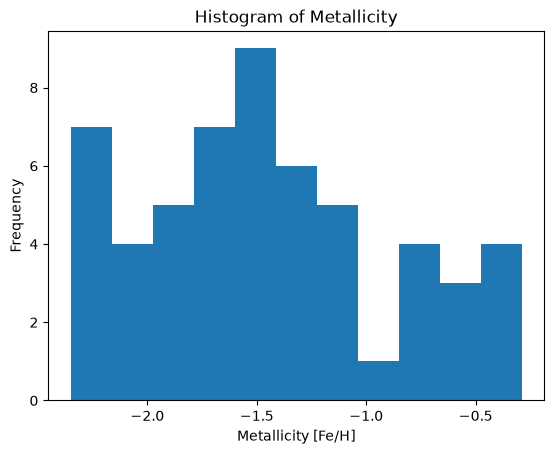

In [53]:
import matplotlib.pyplot as plt
plt.hist(feh, bins=11) #plots a histogram of the dataframe made from the metallicity column. Bin number controls how many divisions it is separated into. 
#Since the differences in metallicity are quite small, I decided it was appropriate to split it into more bins to capture the details of the data.  
# Splitting it into too many bins would have made the histogram not smooth enough to draw meaningful conclusions from, however. 
plt.title('Histogram of Metallicity')
plt.ylabel('Frequency')
plt.xlabel('Metallicity [Fe/H]')
plt.show()

We see that metallicity is weakly bimodal, with a spike at the lowest metallicities around -2.3 and another between ~-1.8 and -1.2. This is an indicator of accreted globular clusters (make sure to explain why this is in the video)

# Working with Merged File

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None) #this makes it so that when I print the csv file it will show me all the columns
df = pd.read_csv('GC_Merged_Table.csv') #importing the merged file into my notebook so that I can work on it without clashing with others
df.head(1) #This prints only the first row of my table so that I can see the names of all the columns


,ID,Name_x,RA,DEC,L,B,R_Sun,R_gc,X,Y,Z,v_r,v_r_e,v_LSR,sig_v,sig_v_e,c,r_c,r_h,mu_V,rho_0,lg_tc,lg_th,Class,AltName,Mstar,rh,C5,Age_x,FeH_x,Name_y,FeH_y,Age_y,Age_err,Method,Figs,Range,HBtype,R_G,M_V,v_e0,log_sigma_0
0,NGC104,47 Tuc,00:24:05.67,-72:04:52.6,305.89,-44.89,4.5,7.4,1.9,-2.6,-3.1,-18.0,0.1,-26.7,11.0,0.3,2.07,0.36,3.17,14.38,4.88,7.84,9.55,GC,47Tuc,6.46,7.1,0.92,12.8,-0.76,47Tuc,-0.76,11.75,0.25,V,14,11.50–11.75,-0.99,7.4,-9.42,54.8,5.061


In [3]:
#I wish to identify the globular clusters with low metallicity. 
#I will filter them by having a metallicity less than -2.0, as this will comfortably capture all GCs in the lower mode.
#The combined dataset has two columns for metallicity, one from the Krause paper and one from the vandenberg paper
import numpy as np
GC_data_array = np.array(df, dtype=object) #turning the data into an array to try print just one column
#print(GC_data_array[:,29]) #extracting one of the metallicity columns
#print(GC_data_array[:,31]) #extracting the other metallicity column
GC_data_array[:,29]==GC_data_array[:,31] #checking if the metallicity columns are identical (i printed it once to check and then stopped printing it)
metallicity1 = GC_data_array[:,29] #defining new variables for metallicity with the combined dataset, with the two metallicity columns
metallicity2 = GC_data_array[:,31]

FeH1 = GC_data_array[:,29]
counter1 = 0 #creates a counter
low_metallicity_FeH_vals1 = [] #list of 0s to add metallicities of low metallicity GCs after they are identified by the loop
low_metallicity_indexes1 = [] #same as above but to add the indexes 
for item in FeH1:
    if item < -2: 
        print(item, counter1) #prints the value of the item followed by its index
        low_metallicity_FeH_vals1.append(item) #adds the metallicity of the item to the list of relevant GCs
        low_metallicity_indexes1.append(counter1) #adds the index of the item to the list of relevant GCs
    else:
        print('not relevant') #shows which values are not relevant
    counter1 = counter1 + 1 #makes it so that the value of the counter increases every loop to index correctly

print('Metallicity of relevant globular clusters=',low_metallicity_FeH_vals1)
print('index of relevant globular clusters=',low_metallicity_indexes1)
#There are less globular clusters with metallicity<-2 than the above histogram says there should be. 
# This is because this is only dealing with the combined dataset which is restricted to the GCs which are present in all 3 datasets


not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
-2.27 7
not relevant
not relevant
not relevant
not relevant
not relevant
-2.2 13
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
-2.1 25
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
-2.33 48
not relevant
-2.33 50
Metallicity of relevant globular clusters= [-2.27, -2.2, -2.1, -2.33, -2.33]
index of relevant globular clusters= [7, 13, 25, 48, 50]


In [4]:
#Do the exact same thing for the second column of metallicity data to check if there are any which are low metallicity in one column but not the other
counter2 = 0 #creates a counter
low_metallicity_FeH_vals2 = [] #list of 0s to add metallicities of low metallicity GCs after they are identified by the loop
low_metallicity_indexes2 = [] #same as above but to add the indexes 
normal_metallicity_vals2 = []
normal_metallicity_indexes2 = [] #to add other GCs to to help with plotting
FeH2 = GC_data_array[:,31]
for item in FeH2:
    if item < -2: 
        print(item, counter2) #prints the value of the item followed by its index
        low_metallicity_FeH_vals2.append(item) #adds the metallicity of the item to the list of relevant GCs
        low_metallicity_indexes2.append(counter2) #adds the index of the item to the list of relevant GCs
    else:
        print('not relevant') #shows which values are not relevant
        normal_metallicity_vals2.append(item)
        normal_metallicity_indexes2.append(counter2)
    counter2 = counter2 + 1 #makes it so that the value of the counter increases every loop to index correctly

print('Metallicity of relevant globular clusters=',low_metallicity_FeH_vals2)
print('index of relevant globular clusters=',low_metallicity_indexes2)
# this column had two more GCs with metallicity below -2. Use this list for further analysis as it is better to over-include than under. 

not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
-2.27 7
not relevant
-2.06 9
-2.3 10
not relevant
not relevant
-2.31 13
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
-2.35 25
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
not relevant
-2.33 48
not relevant
-2.33 50
Metallicity of relevant globular clusters= [-2.27, -2.06, -2.3, -2.31, -2.35, -2.33, -2.33]
index of relevant globular clusters= [7, 9, 10, 13, 25, 48, 50]


In [5]:
#FOR ASHTON AND VIX
lm_GC_indexes_list = low_metallicity_indexes2

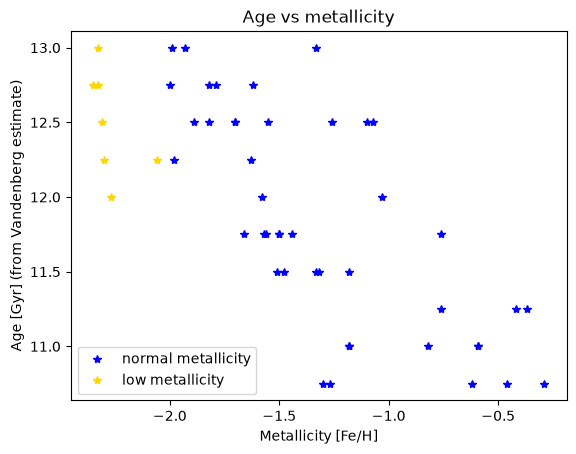

In [25]:
#I wish to plot all of the Globular Clusters by age, and to identify on that plot the low-metallicity globular clusters so that it is possible to see if they have are younger
#Younger low-metallicity Globular Clusters are more likely to be accreted.
#this also will provide another check for outliers that may have been missed by the metallciity analysis

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colours

norm_feh_age = GC_data_array[(normal_metallicity_indexes2),32] #using the Agey column because it is from the vandenberg paper, which had very convincing Age findings
low_feh_age = GC_data_array[(low_metallicity_indexes2),32]

plt.plot(normal_metallicity_vals2, list(norm_feh_age), '*', color = 'blue', label = 'normal metallicity')
plt.plot(low_metallicity_FeH_vals2, list(low_feh_age), '*', color = 'gold', label = 'low metallicity')
plt.xlabel('Metallicity [Fe/H]')
plt.ylabel('Age [Gyr] (from Vandenberg estimate)')
plt.legend(loc='lower left')
plt.title('Age vs metallicity')
plt.show()

In [22]:
norm_feh_age = GC_data_array[(normal_metallicity_indexes2),32] #using the Agey column because it is from the vandenberg paper, which had very convincing Age findings
low_feh_age = GC_data_array[[low_metallicity_indexes2],32]
print(normal_metallicity_vals2), print(norm_feh_age)
len(normal_metallicity_vals2)==len(norm_feh_age)
print(len(normal_metallicity_vals2))
print(len(list(norm_feh_age)))

[-0.76, -1.32, -1.3, -1.27, -1.18, -1.18, -1.51, -1.89, -1.5, -1.7, -1.33, -0.29, -1.63, -1.18, -1.98, -1.82, -1.03, -1.58, -1.33, -1.57, -0.37, -0.62, -0.59, -1.07, -1.99, -0.46, -1.79, -1.82, -1.5, -0.42, -0.59, -0.76, -1.7, -1.62, -1.44, -1.26, -1.1, -1.55, -2.0, -1.93, -0.82, -1.56, -1.48, -1.66]
[11.75 11.5 10.75 10.75 11.0 11.0 11.5 12.5 11.75 12.5 11.5 10.75 12.25
 11.5 12.25 12.75 12.0 12.0 13.0 11.75 11.25 10.75 11.0 12.5 13.0 10.75
 12.75 12.5 11.75 11.25 11.0 11.25 12.5 12.75 11.75 12.5 12.5 12.5 12.75
 13.0 11.0 11.75 11.5 11.75]
44
44
